Is GPU available? True
GPU Name: Tesla P100-PCIE-16GB


Pairing modalities: 100%|██████████| 250/250 [00:01<00:00, 158.46it/s]


Found 250 valid cases.
Image shape: torch.Size([3, 192, 192, 30])
Mask shape: torch.Size([1, 192, 192, 30])


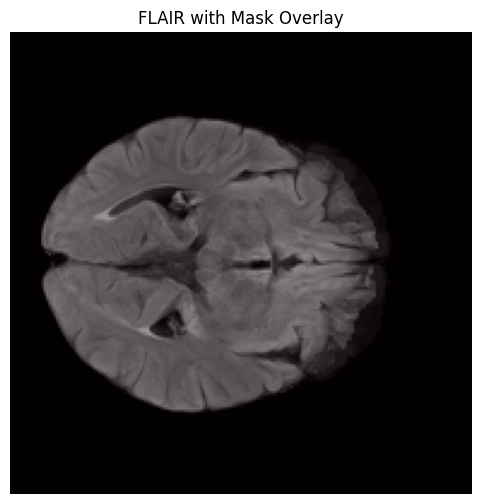

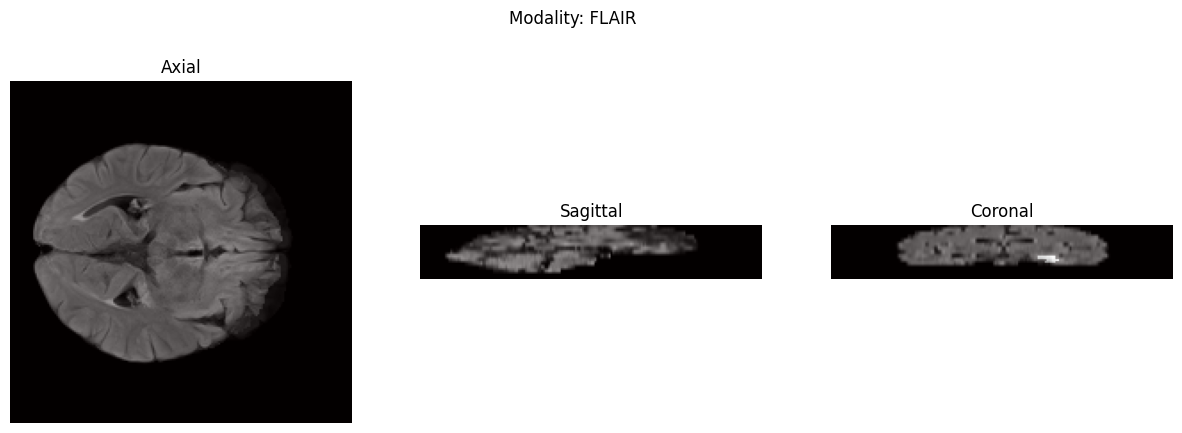

Pairing modalities: 100%|██████████| 250/250 [00:00<00:00, 337.08it/s]



Epoch 1/200


Train Loss: 0.9879 | Val Dice: 0.0321 | Val F1: 0.0322
--- New Best Ensemble Saved (epoch 1) ---

Epoch 2/200


Training:  82%|████████▏ | 143/175 [03:00<00:38,  1.19s/it]

In [ ]:
# file: isles_dataset_resampled.py
!pip install -q nibabel segmentation-models-pytorch monai nilearn timm
import os
import glob
import torch
import numpy as np
import pandas as pd
import nibabel as nib
from tqdm import tqdm
from torch.utils.data import Dataset
from scipy.ndimage import zoom

print(f"Is GPU available? {torch.cuda.is_available()}")
print(f"GPU Name: {torch.cuda.get_device_name(0)}")

SEARCH_ROOT = "/kaggle/input/"


def find_real_nii_file(path_pattern: str) -> str | None:
    matches = glob.glob(path_pattern, recursive=True)
    for path in matches:
        if os.path.isdir(path):
            nii_files = glob.glob(os.path.join(path, "**", "*.nii*"), recursive=True)
            if nii_files:
                return nii_files[0]
        elif path.endswith(".nii") or path.endswith(".nii.gz"):
            return path
    return None


def get_isles_dataframe(search_path: str) -> pd.DataFrame:
    mask_files = glob.glob(
        os.path.join(search_path, "**", "*_msk.nii*"),
        recursive=True,
    )

    data = []

    for mask_path in tqdm(mask_files, desc="Pairing modalities"):
        filename = os.path.basename(mask_path)
        parts = filename.split("_")
        case_id = parts[0]
        session_id = parts[1]

        base_dir = mask_path.split("derivatives")[0]
        case_folder = os.path.join(base_dir, case_id, session_id)

        flair = find_real_nii_file(
            os.path.join(case_folder, "anat", "*FLAIR.nii*")
        )

        adc = find_real_nii_file(
            os.path.join(case_folder, "dwi", "*adc.nii*")
        )

        dwi = find_real_nii_file(
            os.path.join(case_folder, "dwi", "*dwi.nii*")
        )

        if flair and adc and dwi:
            data.append(
                {
                    "case_id": case_id,
                    "flair": flair,
                    "adc": adc,
                    "dwi": dwi,
                    "mask": mask_path,
                }
            )

    return pd.DataFrame(data)


class Stroke3DDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame):
        self.df = dataframe.reset_index(drop=True)

    def __len__(self) -> int:
        return len(self.df)

    @staticmethod
    def normalize(data: np.ndarray) -> np.ndarray:
        return (data - data.min()) / (data.max() - data.min() + 1e-8)

    @staticmethod
    def load_nii(path: str) -> np.ndarray:
        return nib.load(path).get_fdata().astype(np.float32)

    @staticmethod
    def resample_to_target(
        volume: np.ndarray,
        target_shape: tuple[int, int, int],
        is_mask: bool = False,
    ) -> np.ndarray:
        if volume.shape == target_shape:
            return volume

        zoom_factors = [
            t / s for s, t in zip(volume.shape, target_shape)
        ]

        order = 0 if is_mask else 1  # nearest for mask

        return zoom(volume, zoom_factors, order=order)

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]

        flair = self.load_nii(row["flair"])
        adc = self.load_nii(row["adc"])
        dwi = self.load_nii(row["dwi"])
        mask = self.load_nii(row["mask"])

        target_shape = mask.shape

        flair = self.resample_to_target(flair, target_shape)
        adc = self.resample_to_target(adc, target_shape)
        dwi = self.resample_to_target(dwi, target_shape)
        mask = self.resample_to_target(mask, target_shape, is_mask=True)

        image = np.stack(
            [
                self.normalize(flair),
                self.normalize(adc),
                self.normalize(dwi),
            ],
            axis=0,
        )

        mask = np.expand_dims(mask, axis=0)

        return torch.from_numpy(image), torch.from_numpy(mask)


if __name__ == "__main__":
    df = get_isles_dataframe(SEARCH_ROOT)

    print(f"Found {len(df)} valid cases.")

    dataset = Stroke3DDataset(df)

    img, msk = dataset[0]

    print("Image shape:", img.shape)
    print("Mask shape:", msk.shape)
import matplotlib.pyplot as plt

# dataset থেকে প্রথম sample নাও
img, msk = dataset[0]

# মধ্যবর্তী slice along z-axis
mid_slice = img.shape[-1] // 2

flair_slice = img[0, :, :, mid_slice].numpy()
mask_slice = msk[0, :, :, mid_slice].numpy()

plt.figure(figsize=(6,6))
plt.imshow(flair_slice, cmap='gray')
plt.imshow(mask_slice, cmap='hot', alpha=0.4)  # mask overlay with transparency
plt.title("FLAIR with Mask Overlay")
plt.axis('off')
plt.show()
import matplotlib.pyplot as plt

def visualize_with_mask(img_tensor, mask_tensor, slice_idx=None, modality=0):
    """
    Visualize a 3D volume slice with mask overlay.
    
    Args:
        img_tensor: torch.Tensor of shape [C, H, W, D]
        mask_tensor: torch.Tensor of shape [1, H, W, D]
        slice_idx: int or tuple of ints (axial, sagittal, coronal). 
                   If None, use mid slices.
        modality: int, channel index (0=FLAIR, 1=ADC, 2=DWI)
    """
    img = img_tensor[modality].numpy()
    mask = mask_tensor[0].numpy()
    
    # mid slices if not provided
    if slice_idx is None:
        slice_idx = (img.shape[2]//2, img.shape[0]//2, img.shape[1]//2)
    
    axial = slice_idx[0]
    sagittal = slice_idx[1]
    coronal = slice_idx[2]

    fig, axes = plt.subplots(1, 3, figsize=(15,5))

    # Axial (H x W)
    axes[0].imshow(img[:, :, axial], cmap='gray')
    axes[0].imshow(mask[:, :, axial], cmap='hot', alpha=0.4)
    axes[0].set_title("Axial")
    axes[0].axis('off')

    # Sagittal (D x H)
    axes[1].imshow(np.rot90(img[sagittal, :, :]), cmap='gray')
    axes[1].imshow(np.rot90(mask[sagittal, :, :]), cmap='hot', alpha=0.4)
    axes[1].set_title("Sagittal")
    axes[1].axis('off')

    # Coronal (D x W)
    axes[2].imshow(np.rot90(img[:, coronal, :]), cmap='gray')
    axes[2].imshow(np.rot90(mask[:, coronal, :]), cmap='hot', alpha=0.4)
    axes[2].set_title("Coronal")
    axes[2].axis('off')

    plt.suptitle(f"Modality: {['FLAIR','ADC','DWI'][modality]}")
    plt.show()


# Example: visualize first sample, FLAIR
visualize_with_mask(dataset[0][0], dataset[0][1])

# Single cell: full pipeline (data pairing, dataset, 70/15/15 split, ensemble training with padding,
# save best ensemble by validation Dice, evaluate on test set, per-case Dice & F1, and simple explainability overlays).
# Requirements: nibabel, monai, segmentation-models-pytorch (optional), sklearn, tqdm, matplotlib, torch
# Run in a notebook cell. Adjust SEARCH_ROOT to your data location if not using Kaggle.

# --- Imports ---
import os
import glob
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.ndimage import zoom
from torch.utils.data import Dataset, DataLoader
from monai.networks.nets import UNet, AttentionUnet, SegResNet, DynUNet
from monai.losses import DiceLoss
from monai.metrics import DiceMetric
from sklearn.metrics import f1_score

# --- Config ---
SEARCH_ROOT = "/kaggle/input/"  # change if needed
CONFIG = {
    "in_channels": 3,
    "out_channels": 1,
    "lr": 1e-4,
    "epochs": 200,
    "batch_size": 1,
    "device": torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    "spatial_multiple": 16,   # pad D,H,W to multiples of this
    "checkpoint_dir": "./checkpoints",
    "seed": 42
}
os.makedirs(CONFIG["checkpoint_dir"], exist_ok=True)
torch.manual_seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])

# ---------------- Data pairing and dataset ----------------
def find_real_nii_file(path_pattern: str) -> str | None:
    matches = glob.glob(path_pattern, recursive=True)
    for path in matches:
        if os.path.isdir(path):
            nii_files = glob.glob(os.path.join(path, "**", "*.nii*"), recursive=True)
            if nii_files:
                return nii_files[0]
        elif path.endswith(".nii") or path.endswith(".nii.gz"):
            return path
    return None

def get_isles_dataframe(search_path: str) -> pd.DataFrame:
    mask_files = glob.glob(os.path.join(search_path, "**", "*_msk.nii*"), recursive=True)
    data = []
    for mask_path in tqdm(mask_files, desc="Pairing modalities"):
        filename = os.path.basename(mask_path)
        parts = filename.split("_")
        if len(parts) < 2:
            continue
        case_id = parts[0]
        session_id = parts[1]
        # base_dir logic: try to find parent case folder
        # If 'derivatives' exists in path, use that split; otherwise use two levels up
        if "derivatives" in mask_path:
            base_dir = mask_path.split("derivatives")[0]
        else:
            base_dir = os.path.dirname(os.path.dirname(mask_path)) + os.sep
        case_folder = os.path.join(base_dir, case_id, session_id)
        flair = find_real_nii_file(os.path.join(case_folder, "anat", "*FLAIR.nii*"))
        adc = find_real_nii_file(os.path.join(case_folder, "dwi", "*adc.nii*"))
        dwi = find_real_nii_file(os.path.join(case_folder, "dwi", "*dwi.nii*"))
        if flair and adc and dwi:
            data.append({"case_id": case_id, "flair": flair, "adc": adc, "dwi": dwi, "mask": mask_path})
    return pd.DataFrame(data)

class Stroke3DDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame):
        self.df = dataframe.reset_index(drop=True)

    def __len__(self) -> int:
        return len(self.df)

    @staticmethod
    def normalize(data: np.ndarray) -> np.ndarray:
        return (data - data.min()) / (data.max() - data.min() + 1e-8)

    @staticmethod
    def load_nii(path: str) -> np.ndarray:
        return nib.load(path).get_fdata().astype(np.float32)

    @staticmethod
    def resample_to_target(volume: np.ndarray, target_shape: tuple[int, int, int], is_mask: bool = False) -> np.ndarray:
        if volume.shape == target_shape:
            return volume
        zoom_factors = [t / s for s, t in zip(volume.shape, target_shape)]
        order = 0 if is_mask else 1
        return zoom(volume, zoom_factors, order=order)

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]
        flair = self.load_nii(row["flair"])
        adc = self.load_nii(row["adc"])
        dwi = self.load_nii(row["dwi"])
        mask = self.load_nii(row["mask"])
        target_shape = mask.shape
        flair = self.resample_to_target(flair, target_shape)
        adc = self.resample_to_target(adc, target_shape)
        dwi = self.resample_to_target(dwi, target_shape)
        mask = self.resample_to_target(mask, target_shape, is_mask=True)
        # ensure mask binary
        mask = (mask > 0.5).astype(np.float32)
        image = np.stack([self.normalize(flair), self.normalize(adc), self.normalize(dwi)], axis=0)
        mask = np.expand_dims(mask, axis=0)
        return torch.from_numpy(image), torch.from_numpy(mask)

# ---------------- Model factory ----------------
def get_ensemble_models():
    m1 = UNet(spatial_dims=3, in_channels=3, out_channels=1,
              channels=(16, 32, 64, 128, 256), strides=(2, 2, 2, 2)).to(CONFIG["device"])
    m2 = AttentionUnet(spatial_dims=3, in_channels=3, out_channels=1,
                       channels=(16, 32, 64, 128, 256), strides=(2, 2, 2, 2)).to(CONFIG["device"])
    m3 = SegResNet(spatial_dims=3, in_channels=3, out_channels=1, init_filters=16).to(CONFIG["device"])
    m4 = DynUNet(
        spatial_dims=3, in_channels=3, out_channels=1,
        kernel_size=[[3,3,3]]*5, strides=[[1,1,1]] + [[2,2,2]]*4,
        upsample_kernel_size=[[2,2,2]]*4, filters=[16, 32, 64, 128, 256]
    ).to(CONFIG["device"])
    return [m1, m2, m3, m4]

# ---------------- Utilities for shapes & padding ----------------
def to_monai_shape(x: torch.Tensor):
    # dataset returns [B, C, H, W, D] -> MONAI expects [B, C, D, H, W]
    return x.permute(0, 1, 4, 2, 3).contiguous()

def pad_to_multiple_tensor(x: torch.Tensor, multiple: int):
    # x: [B, C, D, H, W]
    _, _, D, H, W = x.shape
    pad_d = (multiple - (D % multiple)) % multiple
    pad_h = (multiple - (H % multiple)) % multiple
    pad_w = (multiple - (W % multiple)) % multiple
    pad = (0, pad_w, 0, pad_h, 0, pad_d)  # (W_left, W_right, H_left, H_right, D_left, D_right)
    if any([pad_d, pad_h, pad_w]):
        x = F.pad(x, pad, mode="constant", value=0)
    return x, pad

def unpad_tensor(x: torch.Tensor, pad):
    if pad is None:
        return x
    w_r = pad[1]; h_r = pad[3]; d_r = pad[5]
    if d_r == 0 and h_r == 0 and w_r == 0:
        return x
    D, H, W = x.shape[2], x.shape[3], x.shape[4]
    d_end = D - d_r if d_r != 0 else D
    h_end = H - h_r if h_r != 0 else H
    w_end = W - w_r if w_r != 0 else W
    return x[:, :, :d_end, :h_end, :w_end]

# ---------------- Training and validation loops ----------------
def train_one_epoch(models, loader, optimizers, loss_fn):
    for m in models: m.train()
    total_loss = 0.0
    n_batches = 0
    for images, masks in tqdm(loader, desc="Training", leave=False):
        images = to_monai_shape(images).to(CONFIG["device"], dtype=torch.float32)
        masks = to_monai_shape(masks).to(CONFIG["device"], dtype=torch.float32)
        images, pad = pad_to_multiple_tensor(images, CONFIG["spatial_multiple"])
        masks, _ = pad_to_multiple_tensor(masks, CONFIG["spatial_multiple"])
        epoch_loss = 0.0
        for i, model in enumerate(models):
            optimizers[i].zero_grad()
            output = model(images)
            loss = loss_fn(output, masks)
            loss.backward()
            optimizers[i].step()
            epoch_loss += loss.item()
        total_loss += (epoch_loss / len(models))
        n_batches += 1
    return total_loss / max(1, n_batches)

def validate_ensemble(models, loader):
    for m in models: m.eval()
    dice_metric = DiceMetric(include_background=True, reduction="mean")
    all_f1s = []
    with torch.no_grad():
        for images, masks in tqdm(loader, desc="Validating", leave=False):
            images = to_monai_shape(images).to(CONFIG["device"], dtype=torch.float32)
            masks = to_monai_shape(masks).to(CONFIG["device"], dtype=torch.float32)
            images, pad = pad_to_multiple_tensor(images, CONFIG["spatial_multiple"])
            masks, _ = pad_to_multiple_tensor(masks, CONFIG["spatial_multiple"])
            preds = []
            for model in models:
                p = torch.sigmoid(model(images))
                if p.shape != masks.shape:
                    p = F.interpolate(p, size=masks.shape[2:], mode="trilinear", align_corners=False)
                preds.append(p)
            ensemble_pred = (0.1*preds[0] + 0.1*preds[1] + 0.4*preds[2] + 0.4*preds[3])
            final_mask = (ensemble_pred > 0.5).float()
            bin_masks = (masks > 0.5).float()
            # Dice
            try:
                dice_metric(y_pred=final_mask, y=bin_masks)
            except Exception:
                if final_mask.shape != bin_masks.shape:
                    final_mask = F.interpolate(final_mask, size=bin_masks.shape[2:], mode="nearest")
                    dice_metric(y_pred=final_mask, y=bin_masks)
                else:
                    raise
            # F1 per batch item
            final_mask_unpadded = unpad_tensor(final_mask, pad)
            bin_masks_unpadded = unpad_tensor(bin_masks, pad)
            fp = final_mask_unpadded.cpu().numpy()
            gt = bin_masks_unpadded.cpu().numpy()
            B = fp.shape[0]
            for b in range(B):
                y_pred_flat = fp[b].ravel()
                y_true_flat = gt[b].ravel()
                if y_true_flat.sum() == 0 and y_pred_flat.sum() == 0:
                    f1 = 1.0
                else:
                    f1 = f1_score(y_true_flat, y_pred_flat, zero_division=0)
                all_f1s.append(f1)
    mean_dice = dice_metric.aggregate().item()
    dice_metric.reset()
    mean_f1 = float(np.mean(all_f1s)) if len(all_f1s) > 0 else 0.0
    return mean_dice, mean_f1

# ---------------- Evaluation utilities ----------------
def evaluate_and_save_per_case(models, loader, df_subset, out_dir="./eval_outputs", save_nifti=True):
    os.makedirs(out_dir, exist_ok=True)
    for m in models: m.eval()
    dice_metric = DiceMetric(include_background=True, reduction="mean")
    records = []
    with torch.no_grad():
        for idx, (img, msk) in enumerate(tqdm(loader, desc="Test Eval")):
            case_id = df_subset.iloc[idx]["case_id"] if "case_id" in df_subset.columns else f"case_{idx}"
            images = to_monai_shape(img).to(CONFIG["device"], dtype=torch.float32)
            masks = to_monai_shape(msk).to(CONFIG["device"], dtype=torch.float32)
            images, pad = pad_to_multiple_tensor(images, CONFIG["spatial_multiple"])
            masks, _ = pad_to_multiple_tensor(masks, CONFIG["spatial_multiple"])
            preds = []
            for model in models:
                p = torch.sigmoid(model(images))
                if p.shape != masks.shape:
                    p = F.interpolate(p, size=masks.shape[2:], mode="trilinear", align_corners=False)
                preds.append(p)
            ensemble = (0.1*preds[0] + 0.1*preds[1] + 0.4*preds[2] + 0.4*preds[3])
            pred_bin = (ensemble > 0.5).float()
            gt_bin = (masks > 0.5).float()
            try:
                dice_metric(y_pred=pred_bin, y=gt_bin)
            except Exception:
                if pred_bin.shape != gt_bin.shape:
                    pred_bin = F.interpolate(pred_bin, size=gt_bin.shape[2:], mode="nearest")
                    dice_metric(y_pred=pred_bin, y=gt_bin)
                else:
                    raise
            pred_unp = unpad_tensor(pred_bin, pad)
            gt_unp = unpad_tensor(gt_bin, pad)
            pred_np = pred_unp.cpu().numpy()
            gt_np = gt_unp.cpu().numpy()
            y_pred_flat = pred_np[0].ravel()
            y_true_flat = gt_np[0].ravel()
            if y_true_flat.sum() == 0 and y_pred_flat.sum() == 0:
                f1 = 1.0
            else:
                f1 = f1_score(y_true_flat, y_pred_flat, zero_division=0)
            records.append({"case_id": case_id, "f1": float(f1)})
            if save_nifti:
                mask_path = df_subset.iloc[idx]["mask"]
                try:
                    ref_nii = nib.load(mask_path)
                    affine = ref_nii.affine
                except Exception:
                    affine = np.eye(4)
                pred_vol = pred_unp.cpu().numpy()[0, 0].astype(np.uint8)
                out_path = os.path.join(out_dir, f"{case_id}_pred.nii.gz")
                nib.save(nib.Nifti1Image(pred_vol, affine), out_path)
    mean_dice = dice_metric.aggregate().item()
    dice_metric.reset()
    df_out = pd.DataFrame(records)
    df_out["dice"] = float(mean_dice)
    csv_path = os.path.join(out_dir, "per_case_metrics.csv")
    df_out.to_csv(csv_path, index=False)
    return float(mean_dice), float(df_out["f1"].mean()), csv_path

# ---------------- Explainability (simple overlay) ----------------
def visualize_prediction_overlay(img_tensor, mask_tensor, pred_tensor, modality=0):
    # img_tensor: [C,H,W,D], mask_tensor: [1,H,W,D], pred_tensor: [1,H,W,D]
    img = img_tensor[modality].numpy()
    mask = mask_tensor[0].numpy()
    pred = pred_tensor[0].numpy()
    mid = img.shape[2] // 2
    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1); plt.imshow(img[:,:,mid], cmap="gray"); plt.title("Input (mid slice)"); plt.axis("off")
    plt.subplot(1,3,2); plt.imshow(img[:,:,mid], cmap="gray"); plt.imshow(mask[:,:,mid], cmap="Reds", alpha=0.4); plt.title("Ground Truth"); plt.axis("off")
    plt.subplot(1,3,3); plt.imshow(img[:,:,mid], cmap="gray"); plt.imshow(pred[:,:,mid], cmap="Reds", alpha=0.4); plt.title("Prediction"); plt.axis("off")
    plt.show()

# ---------------- Main execution ----------------
if __name__ == "__main__":
    # Prepare dataframe and splits
    df = get_isles_dataframe(SEARCH_ROOT)
    if len(df) == 0:
        raise RuntimeError("No valid cases found. Check file naming and folder structure.")
    # 70/15/15 split
    train_df = df.sample(frac=0.7, random_state=CONFIG["seed"])
    remain = df.drop(train_df.index)
    val_df = remain.sample(frac=0.5, random_state=CONFIG["seed"])
    test_df = remain.drop(val_df.index)
    train_ds = Stroke3DDataset(train_df.reset_index(drop=True))
    val_ds = Stroke3DDataset(val_df.reset_index(drop=True))
    test_ds = Stroke3DDataset(test_df.reset_index(drop=True))
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=0, pin_memory=False)
    val_loader = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=0, pin_memory=False)
    test_loader = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=0, pin_memory=False)

    # Build ensemble models and optimizers
    models = get_ensemble_models()
    optimizers = [torch.optim.Adam(m.parameters(), lr=CONFIG["lr"]) for m in models]
    loss_fn = DiceLoss(sigmoid=True)

    best_val_dice = -1.0
    best_epoch = -1
    for epoch in range(CONFIG["epochs"]):
        print(f"\nEpoch {epoch+1}/{CONFIG['epochs']}")
        train_loss = train_one_epoch(models, train_loader, optimizers, loss_fn)
        val_dice, val_f1 = validate_ensemble(models, val_loader)
        print(f"Train Loss: {train_loss:.4f} | Val Dice: {val_dice:.4f} | Val F1: {val_f1:.4f}")
        if val_dice > best_val_dice:
            best_val_dice = val_dice
            best_epoch = epoch + 1
            for i, m in enumerate(models):
                torch.save(m.state_dict(), os.path.join(CONFIG["checkpoint_dir"], f"best_model_{i}.pth"))
            print(f"--- New Best Ensemble Saved (epoch {best_epoch}) ---")

    # Load best checkpoints into models (to ensure evaluation uses best weights)
    for i, m in enumerate(models):
        ckpt = os.path.join(CONFIG["checkpoint_dir"], f"best_model_{i}.pth")
        if os.path.exists(ckpt):
            m.load_state_dict(torch.load(ckpt, map_location=CONFIG["device"]))
            print(f"Loaded checkpoint: {ckpt}")
        else:
            print(f"Warning: checkpoint not found for model {i}: {ckpt}")

    # Evaluate on test set and save per-case metrics + predicted NIfTIs
    print("\nEvaluating best ensemble on test set...")
    test_dice, test_f1, csv_path = evaluate_and_save_per_case(models, test_loader, test_df.reset_index(drop=True), out_dir="./eval_outputs", save_nifti=True)
    print(f"Test Dice: {test_dice:.4f} | Test F1: {test_f1:.4f}")
    print(f"Per-case metrics saved to: {csv_path}")

    # Show explainability overlay for first test case (if exists)
    if len(test_ds) > 0:
        img, msk = test_ds[0]  # [C,H,W,D], [1,H,W,D]
        images = to_monai_shape(img.unsqueeze(0)).to(CONFIG["device"], dtype=torch.float32)
        images, pad = pad_to_multiple_tensor(images, CONFIG["spatial_multiple"])
        with torch.no_grad():
            preds = []
            for m in models:
                p = torch.sigmoid(m(images))
                if p.shape[2:] != msk.shape[1:]:
                    p = F.interpolate(p, size=msk.shape[1:], mode="trilinear", align_corners=False)
                preds.append(p)
            ensemble = (0.1*preds[0] + 0.1*preds[1] + 0.4*preds[2] + 0.4*preds[3])
            pred_bin = (ensemble > 0.5).float()
            pred_unp = unpad_tensor(pred_bin, pad)[0].cpu()
        # visualize mid-slice overlay (FLAIR channel = modality 0)
        visualize_prediction_overlay(img, msk, pred_unp, modality=0)
    else:
        print("No test cases to visualize.")


In [ ]:
# ---------------- Resume Training from Checkpoint ----------------
if __name__ == "__main__":
    # Reload dataframe and splits (same seed ensures same split)
    df = get_isles_dataframe(SEARCH_ROOT)
    train_df = df.sample(frac=0.7, random_state=CONFIG["seed"])
    remain = df.drop(train_df.index)
    val_df = remain.sample(frac=0.5, random_state=CONFIG["seed"])
    test_df = remain.drop(val_df.index)

    train_ds = Stroke3DDataset(train_df.reset_index(drop=True))
    val_ds = Stroke3DDataset(val_df.reset_index(drop=True))
    test_ds = Stroke3DDataset(test_df.reset_index(drop=True))

    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False)

    # Build ensemble models
    models = get_ensemble_models()

    # Load best checkpoints from previous run (up to epoch 150)
    for i, m in enumerate(models):
        ckpt = os.path.join(CONFIG["checkpoint_dir"], f"best_model_{i}.pth")
        if os.path.exists(ckpt):
            m.load_state_dict(torch.load(ckpt, map_location=CONFIG["device"]))
            print(f"Resumed from checkpoint: {ckpt}")
        else:
            print(f"Warning: checkpoint not found for model {i}")

    # Optimizers and loss
    optimizers = [torch.optim.Adam(m.parameters(), lr=CONFIG["lr"]) for m in models]
    loss_fn = DiceLoss(sigmoid=True)

    # Resume training from epoch 151 to 160
    best_val_dice = -1.0
    for epoch in range(151, 161):
        print(f"\nEpoch {epoch}/160")
        train_loss = train_one_epoch(models, train_loader, optimizers, loss_fn)
        val_dice, val_f1 = validate_ensemble(models, val_loader)
        print(f"Train Loss: {train_loss:.4f} | Val Dice: {val_dice:.4f} | Val F1: {val_f1:.4f}")

        if val_dice > best_val_dice:
            best_val_dice = val_dice
            for i, m in enumerate(models):
                torch.save(m.state_dict(), os.path.join(CONFIG["checkpoint_dir"], f"best_model_{i}.pth"))
            print(f"--- New Best Ensemble Saved (epoch {epoch}) ---")

    # Evaluate again on test set after epoch 160
    print("\nEvaluating ensemble after epoch 160...")
    test_dice, test_f1, csv_path = evaluate_and_save_per_case(
        models, test_loader, test_df.reset_index(drop=True),
        out_dir="./eval_outputs_resume", save_nifti=True
    )
    print(f"Test Dice: {test_dice:.4f} | Test F1: {test_f1:.4f}")
    print(f"Per-case metrics saved to: {csv_path}")

    # Optional: visualize overlay for first test case
    if len(test_ds) > 0:
        img, msk = test_ds[0]
        images = to_monai_shape(img.unsqueeze(0)).to(CONFIG["device"], dtype=torch.float32)
        images, pad = pad_to_multiple_tensor(images, CONFIG["spatial_multiple"])
        with torch.no_grad():
            preds = []
            for m in models:
                p = torch.sigmoid(m(images))
                if p.shape[2:] != msk.shape[1:]:
                    p = F.interpolate(p, size=msk.shape[1:], mode="trilinear", align_corners=False)
                preds.append(p)
            ensemble = (0.1*preds[0] + 0.1*preds[1] + 0.4*preds[2] + 0.4*preds[3])
            pred_bin = (ensemble > 0.5).float()
            pred_unp = unpad_tensor(pred_bin, pad)[0].cpu()
        visualize_prediction_overlay(img, msk, pred_unp, modality=0)


In [ ]:
# ---------------- Resume Training: Epochs 161 to 170 ----------------
if __name__ == "__main__":
    # Reload dataframe and splits (same seed ensures same split)
    df = get_isles_dataframe(SEARCH_ROOT)
    train_df = df.sample(frac=0.7, random_state=CONFIG["seed"])
    remain = df.drop(train_df.index)
    val_df = remain.sample(frac=0.5, random_state=CONFIG["seed"])
    test_df = remain.drop(val_df.index)

    train_ds = Stroke3DDataset(train_df.reset_index(drop=True))
    val_ds = Stroke3DDataset(val_df.reset_index(drop=True))
    test_ds = Stroke3DDataset(test_df.reset_index(drop=True))

    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False)

    # Build ensemble models
    models = get_ensemble_models()

    # Load best checkpoints from previous runs (≤160)
    for i, m in enumerate(models):
        ckpt = os.path.join(CONFIG["checkpoint_dir"], f"best_model_{i}.pth")
        if os.path.exists(ckpt):
            m.load_state_dict(torch.load(ckpt, map_location=CONFIG["device"]))
            print(f"Resumed from checkpoint: {ckpt}")
        else:
            print(f"Warning: checkpoint not found for model {i}")

    # Optimizers and loss
    optimizers = [torch.optim.Adam(m.parameters(), lr=CONFIG["lr"]) for m in models]
    loss_fn = DiceLoss(sigmoid=True)

    # Resume training from epoch 161 to 170
    best_val_dice = 0.7079   # ⚠️ চাইলে এখানে আগের best carry-over করতে পারো
    for epoch in range(161, 171):
        print(f"\nEpoch {epoch}/170")
        train_loss = train_one_epoch(models, train_loader, optimizers, loss_fn)
        val_dice, val_f1 = validate_ensemble(models, val_loader)
        print(f"Train Loss: {train_loss:.4f} | Val Dice: {val_dice:.4f} | Val F1: {val_f1:.4f}")

        if val_dice > best_val_dice:
            best_val_dice = val_dice
            for i, m in enumerate(models):
                torch.save(m.state_dict(), os.path.join(CONFIG["checkpoint_dir"], f"best_model_{i}.pth"))
            print(f"--- New Best Ensemble Saved (epoch {epoch}) ---")

    # Evaluate again on test set after epoch 170
    print("\nEvaluating ensemble after epoch 170...")
    test_dice, test_f1, csv_path = evaluate_and_save_per_case(
        models, test_loader, test_df.reset_index(drop=True),
        out_dir="./eval_outputs_resume2", save_nifti=True
    )
    print(f"Test Dice: {test_dice:.4f} | Test F1: {test_f1:.4f}")
    print(f"Per-case metrics saved to: {csv_path}")

    # Optional: visualize overlay for first test case
    if len(test_ds) > 0:
        img, msk = test_ds[0]
        images = to_monai_shape(img.unsqueeze(0)).to(CONFIG["device"], dtype=torch.float32)
        images, pad = pad_to_multiple_tensor(images, CONFIG["spatial_multiple"])
        with torch.no_grad():
            preds = []
            for m in models:
                p = torch.sigmoid(m(images))
                if p.shape[2:] != msk.shape[1:]:
                    p = F.interpolate(p, size=msk.shape[1:], mode="trilinear", align_corners=False)
                preds.append(p)
            ensemble = (0.1*preds[0] + 0.1*preds[1] + 0.4*preds[2] + 0.4*preds[3])
            pred_bin = (ensemble > 0.5).float()
            pred_unp = unpad_tensor(pred_bin, pad)[0].cpu()
        visualize_prediction_overlay(img, msk, pred_unp, modality=0)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from skimage import measure

def visualize_prediction_contours(img_tensor, gt_mask_tensor, pred_mask_tensor, modality=0):
    """
    Show mid-slice with GT and Predicted mask contours.
    GT = yellow, Pred = red
    """
    img = img_tensor[modality].numpy()
    gt = gt_mask_tensor[0].numpy()
    pred = pred_mask_tensor[0].numpy()

    mid = img.shape[2] // 2
    slice_img = img[:, :, mid]
    slice_gt = gt[:, :, mid]
    slice_pred = pred[:, :, mid]

    fig, ax = plt.subplots(figsize=(6,6))
    ax.imshow(slice_img, cmap="gray")

    # GT contours (yellow)
    contours_gt = measure.find_contours(slice_gt, 0.5)
    for c in contours_gt:
        ax.plot(c[:, 1], c[:, 0], color="yellow", linewidth=2, label="GT")

    # Pred contours (red)
    contours_pred = measure.find_contours(slice_pred, 0.5)
    for c in contours_pred:
        ax.plot(c[:, 1], c[:, 0], color="red", linewidth=2, label="Prediction")

    # Avoid duplicate legend entries
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys())

    ax.set_title("Stroke Lesion Contours (GT=Yellow, Pred=Red)")
    ax.axis("off")
    plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import binary_erosion, gaussian_filter, zoom

# ---------------- Boundary helper ----------------
def mask_to_boundary(mask2d, thickness=1):
    eroded = binary_erosion(mask2d, iterations=thickness)
    return mask2d ^ eroded

# ---------------- Dice heatmap ----------------
def dice_heatmap(gt, pr, eps=1e-6):
    inter = gt * pr
    return (2 * inter + eps) / (gt + pr + eps)

# ---------------- Alignment helper ----------------
def resample_2d_to_target(arr2d, target_shape, is_mask=True):
    """
    Resample a 2D array to target_shape (H, W).
    - For masks use nearest-neighbor (order=0).
    - For soft maps use bilinear (order=1).
    """
    arr2d = np.asarray(arr2d)
    if arr2d.shape == tuple(target_shape):
        return arr2d
    src_h, src_w = arr2d.shape
    tgt_h, tgt_w = target_shape
    if src_h == 0 or src_w == 0:
        return np.zeros(target_shape, dtype=arr2d.dtype)
    zoom_h = tgt_h / src_h
    zoom_w = tgt_w / src_w
    order = 0 if is_mask else 1
    # scipy.ndimage.zoom expects zoom factors in (rows, cols) order
    return zoom(arr2d, (zoom_h, zoom_w), order=order)

# ---------------- Main visualization ----------------
def visualize_everything(img, gt, pr, modality=0):
    """
    img: torch-like tensor or numpy array [C,H,W,D]
    gt:   [1,H,W,D]
    pr:   [1,H,W,D]  (soft or binary)
    """
    # convert to numpy if tensors
    if hasattr(img, "numpy"):
        img = img.numpy()
    if hasattr(gt, "numpy"):
        gt = gt.numpy()
    if hasattr(pr, "numpy"):
        pr = pr.numpy()

    img = img[modality]     # [H,W,D]
    gt  = gt[0]             # [H,W,D]
    pr  = pr[0]             # [H,W,D]

    D = img.shape[2]
    if D == 0:
        raise ValueError("Image depth is zero.")
    slices = [max(0, D//4), D//2, min(D-1, 3*D//4)]   # multi-slice montage

    fig = plt.figure(figsize=(18, 14))
    im_for_cbar = None

    for i, s in enumerate(slices):
        img2d = img[:, :, s]
        gt2d_raw  = gt[:, :, s]
        pr2d_raw  = pr[:, :, s]

        # Ensure image is 2D float
        img2d = np.asarray(img2d, dtype=np.float32)
        # Determine target shape from image slice
        target_shape = img2d.shape

        # Resample GT and PR to image shape (nearest for masks, bilinear for soft pred)
        gt2d = resample_2d_to_target((gt2d_raw > 0.5).astype(np.uint8), target_shape, is_mask=True)
        # If pr is soft (float), keep soft for dice heatmap; also create binary version
        pr_soft = resample_2d_to_target(pr2d_raw.astype(np.float32), target_shape, is_mask=False)
        pr2d = (pr_soft > 0.5).astype(np.uint8)

        # Boundaries
        gt_b = mask_to_boundary(gt2d)
        pr_b = mask_to_boundary(pr2d)

        # FP / FN
        fp = (pr2d == 1) & (gt2d == 0)
        fn = (pr2d == 0) & (gt2d == 1)
        fp_b = mask_to_boundary(fp.astype(np.uint8))
        fn_b = mask_to_boundary(fn.astype(np.uint8))

        # Dice heatmap (use binary maps)
        dmap = dice_heatmap(gt2d.astype(np.float32), pr2d.astype(np.float32))
        dmap = gaussian_filter(dmap, sigma=1)

        # -------- Row 1: Boundary Overlay --------
        ax1 = plt.subplot(4, len(slices), i+1)
        ax1.imshow(img2d, cmap="gray")
        ax1.contour(gt_b, colors="yellow", linewidths=1.5)
        ax1.contour(pr_b, colors="red", linewidths=1.5)
        ax1.set_title(f"Slice {s}")
        ax1.axis("off")

        # -------- Row 2: GT Boundary only --------
        ax2 = plt.subplot(4, len(slices), i+1+len(slices))
        ax2.imshow(img2d, cmap="gray")
        ax2.contour(gt_b, colors="yellow", linewidths=2)
        ax2.set_title("GT Boundary")
        ax2.axis("off")

        # -------- Row 3: FP / FN --------
        ax3 = plt.subplot(4, len(slices), i+1+2*len(slices))
        ax3.imshow(img2d, cmap="gray")
        ax3.contour(fp_b, colors="cyan", linewidths=1.5)
        ax3.contour(fn_b, colors="magenta", linewidths=1.5)
        ax3.set_title("FP (Cyan) / FN (Magenta)")
        ax3.axis("off")

        # -------- Row 4: Dice Heatmap --------
        ax4 = plt.subplot(4, len(slices), i+1+3*len(slices))
        im = ax4.imshow(dmap, cmap="hot", vmin=0, vmax=1)
        ax4.set_title("Dice Heatmap")
        ax4.axis("off")
        im_for_cbar = im

    if im_for_cbar is not None:
        cbar = fig.colorbar(im_for_cbar, ax=fig.axes, fraction=0.02, pad=0.01)
        cbar.set_label("Local Dice Similarity", rotation=270, labelpad=15)

    plt.suptitle(
        "Ischemic Stroke Segmentation – Qualitative Analysis\n"
        "Row 1: GT (Yellow) + Prediction (Red) Boundaries | "
        "Row 2: GT Boundary | "
        "Row 3: FP (Cyan) / FN (Magenta) | "
        "Row 4: Dice Heatmap",
        fontsize=14
    )

    plt.tight_layout(rect=[0,0,1,0.94])
    plt.show()

# ---------------- CALL (RUN THIS) ----------------
visualize_everything(img, msk, pred_unp, modality=0)
